=== RANDOM FOREST ENHANCED TRAINING ===
Data shape: (101766, 71)
Target distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64
Training set: (81412, 70), Test set: (20354, 70)
Training Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


  File "c:\Users\dinne\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\dinne\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\dinne\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\dinne\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Best Random Forest F1-Score: 0.2469
Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

RANDOM FOREST - TEST SET PERFORMANCE
              precision    recall  f1-score   support

           0       0.91      0.79      0.85     18083
           1       0.19      0.38      0.25      2271

    accuracy                           0.75     20354
   macro avg       0.55      0.58      0.55     20354
weighted avg       0.83      0.75      0.78     20354

AUC-ROC Score: 0.6451

Confusion Matrix:
True Negatives: 14317, False Positives: 3766
False Negatives: 1413, True Positives: 858

Additional Metrics:
Accuracy: 0.7456
Precision: 0.1856
Recall: 0.3778
F1-Score: 0.2489

VISUALIZATIONS


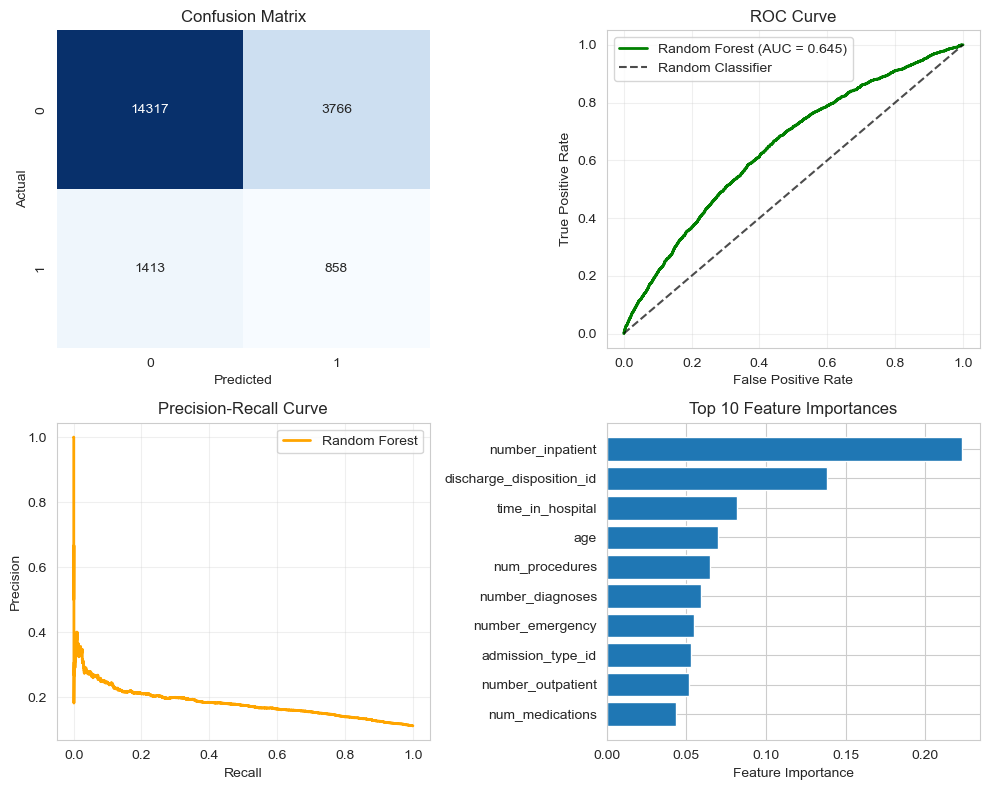


DETAILED PERFORMANCE METRICS
           Metric  Score
          AUC-ROC 0.6451
         Accuracy 0.7456
Balanced Accuracy 0.5848
        Precision 0.1856
           Recall 0.3778
         F1-Score 0.2489
              MCC 0.1274

THRESHOLD OPTIMIZATION ANALYSIS
Optimal Threshold: 0.473
Optimized F1-Score: 0.2603
Optimized Precision: 0.1744
Optimized Recall: 0.5130

Random Forest training and evaluation completed!


In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score, make_scorer, classification_report, balanced_accuracy_score, matthews_corrcoef, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

print("=== RANDOM FOREST ENHANCED TRAINING ===")

# Set up visual settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
file_path = r"C:\Users\dinne\Diabetic-Readmissions-\Data\Processed\cleaned_diabetic_data.csv"
df = pd.read_csv(file_path)
print(f"Data shape: {df.shape}")
print(f"Target distribution:\n{df['readmitted'].value_counts()}")

# Split data
X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Custom scoring
custom_scorers = {
    'f1': 'f1',
    'precision': make_scorer(precision_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1),
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest Pipeline
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.3)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Parameter grid
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 15, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced']
}

print("Training Random Forest...")
rf_grid = GridSearchCV(
    rf_pipeline, 
    rf_param_grid, 
    cv=cv, 
    scoring=custom_scorers,
    refit='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_

print(f"Best Random Forest F1-Score: {rf_grid.best_score_:.4f}")
print(f"Best parameters: {rf_grid.best_params_}")

# Get predictions and probabilities
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
auc_score = roc_auc_score(y_test, y_pred_proba_rf)
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

# Get confusion matrix values
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

# PRINT RESULTS IN REQUESTED FORMAT
print("\n" + "="*50)
print("RANDOM FOREST - TEST SET PERFORMANCE")
print("="*50)

# Classification report
print(classification_report(y_test, y_pred_rf, target_names=['0', '1']))

print(f"AUC-ROC Score: {auc_score:.4f}\n")

# Confusion Matrix details
print("Confusion Matrix:")
print(f"True Negatives: {tn}, False Positives: {fp}")
print(f"False Negatives: {fn}, True Positives: {tp}\n")

# Additional Metrics
print("Additional Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# VISUALIZATIONS
print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)

# 1. Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 2. ROC Curve
plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})', linewidth=2, color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
plt.subplot(2, 2, 3)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_rf)
plt.plot(recall_vals, precision_vals, label='Random Forest', linewidth=2, color='orange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Feature Importance
plt.subplot(2, 2, 4)
try:
    feature_importances = rf_model.named_steps['classifier'].feature_importances_
    feature_names = X.columns
    indices = np.argsort(feature_importances)[::-1][:10]  # Top 10 features
    
    plt.barh(range(len(indices)), feature_importances[indices][::-1])
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Feature Importance')
    plt.title('Top 10 Feature Importances')
except Exception as e:
    plt.text(0.5, 0.5, 'Feature Importance\nNot Available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Feature Importance')

plt.tight_layout()
plt.show()

# Additional Performance Metrics Table
print("\n" + "="*50)
print("DETAILED PERFORMANCE METRICS")
print("="*50)

# Calculate additional metrics
balanced_acc = balanced_accuracy_score(y_test, y_pred_rf)
mcc = matthews_corrcoef(y_test, y_pred_rf)

# Create a metrics table
metrics_data = {
    'Metric': ['AUC-ROC', 'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC'],
    'Score': [f'{auc_score:.4f}', f'{accuracy:.4f}', f'{balanced_acc:.4f}', 
              f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}', f'{mcc:.4f}']
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

# Threshold Optimization Analysis
print("\n" + "="*50)
print("THRESHOLD OPTIMIZATION ANALYSIS")
print("="*50)

# Find optimal threshold using precision-recall curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba_rf)

# Find threshold that maximizes F1-score
best_f1 = 0
optimal_threshold_f1 = 0.5

for i, threshold in enumerate(thresholds):
    if i < len(precision_vals) - 1:
        current_f1 = 2 * (precision_vals[i] * recall_vals[i]) / (precision_vals[i] + recall_vals[i] + 1e-8)
        if current_f1 > best_f1:
            best_f1 = current_f1
            optimal_threshold_f1 = threshold

# Apply optimal threshold
y_pred_optimized = (y_pred_proba_rf >= optimal_threshold_f1).astype(int)

print(f"Optimal Threshold: {optimal_threshold_f1:.3f}")
print(f"Optimized F1-Score: {f1_score(y_test, y_pred_optimized):.4f}")
print(f"Optimized Precision: {precision_score(y_test, y_pred_optimized):.4f}")
print(f"Optimized Recall: {recall_score(y_test, y_pred_optimized):.4f}")

print("\nRandom Forest training and evaluation completed!")